In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pumpkin_df = pd.read_excel('Pumpkin_Seeds_Dataset.xlsx')

In [3]:
pumpkin_df

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness,Class
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207,Çerçevelik
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487,Çerçevelik
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929,Çerçevelik
3,66458,992.051,381.5638,222.5322,67118,290.8899,0.8123,0.9902,0.7396,0.8486,1.7146,0.7624,Çerçevelik
4,66107,998.146,383.8883,220.4545,67117,290.1207,0.8187,0.9850,0.6752,0.8338,1.7413,0.7557,Çerçevelik
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,79637,1224.710,533.1513,190.4367,80381,318.4289,0.9340,0.9907,0.4888,0.6672,2.7996,0.5973,Ürgüp Sivrisi
2496,69647,1084.318,462.9416,191.8210,70216,297.7874,0.9101,0.9919,0.6002,0.7444,2.4134,0.6433,Ürgüp Sivrisi
2497,87994,1210.314,507.2200,222.1872,88702,334.7199,0.8990,0.9920,0.7643,0.7549,2.2828,0.6599,Ürgüp Sivrisi
2498,80011,1182.947,501.9065,204.7531,80902,319.1758,0.9130,0.9890,0.7374,0.7185,2.4513,0.6359,Ürgüp Sivrisi


In [4]:
pumpkin_df.isnull().sum() ## no missing values

,0
Area,0
Perimeter,0
Major_Axis_Length,0
Minor_Axis_Length,0
Convex_Area,0
Equiv_Diameter,0
Eccentricity,0
Solidity,0
Extent,0
Roundness,0


In [5]:
pumpkin_df.Class.unique()

array(['Çerçevelik', 'Ürgüp Sivrisi'], dtype=object)

##**1.Exploratory Data Analysis**

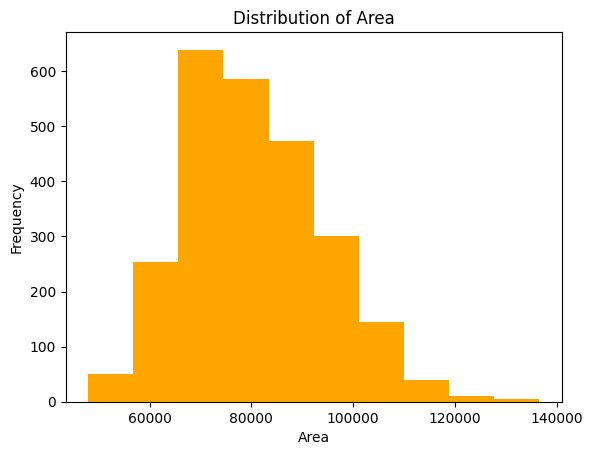

In [6]:
plt.hist(x='Area' , data = pumpkin_df ,color='orange',align = 'mid')
plt.title('Distribution of Area')
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.show()

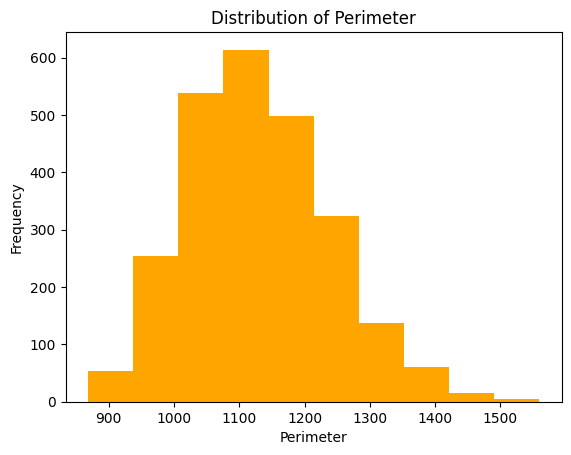

In [7]:
plt.hist(x='Perimeter' , data = pumpkin_df ,color='orange',align = 'mid')
plt.title('Distribution of Perimeter')
plt.xlabel('Perimeter')
plt.ylabel('Frequency')
plt.show()

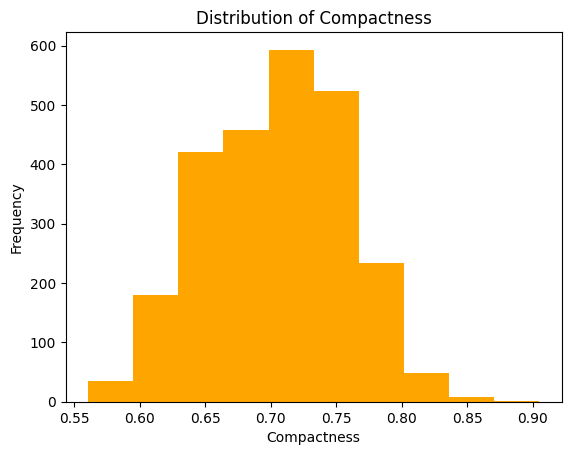

In [8]:
plt.hist(x='Compactness' , data = pumpkin_df ,color='orange',align = 'mid')
plt.title('Distribution of Compactness')
plt.xlabel('Compactness')
plt.ylabel('Frequency')
plt.show()

##**2.Preprocessing**


*   Get rid of useless features
*   Engineer useful features
*   Get rid of outliers
*   Separate numerical and categorical columns
*   Separate train and test sets
*   Separate input and target columns
*   One hot encode categorical features
*   Scale numerical features



In [9]:
numerical_cols = pumpkin_df.select_dtypes(include=np.number).columns
input_features = numerical_cols
target_col = ['Class']

In [10]:
from sklearn.model_selection import train_test_split
train_df,test_df = train_test_split(pumpkin_df , test_size=0.2 , random_state=42)
train_inputs = train_df[input_features].copy()
train_target = train_df[target_col].copy()
test_inputs = test_df[input_features].copy()
test_target = test_df[target_col].copy()

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(train_inputs)
train_inputs = scaler.fit_transform(train_inputs)
test_inputs = scaler.fit_transform(test_inputs)

##**3.Model Selection**

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
model0 = DecisionTreeClassifier(random_state=42)
model0.fit(train_inputs , train_target)
accuracy_score(model0.predict(train_inputs) , train_target) , accuracy_score(model0.predict(test_inputs) , test_target)

(1.0, 0.83)

In [13]:
from sklearn.ensemble import RandomForestClassifier
model1 = RandomForestClassifier(random_state=42)
model1.fit(train_inputs , train_target)
accuracy_score(model1.predict(train_inputs) , train_target) , accuracy_score(model1.predict(test_inputs) , test_target)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


(0.9995, 0.87)

In [14]:
model2 = RandomForestClassifier(n_estimators=100 , max_depth =15, random_state=42)
model2.fit(train_inputs , train_target)
accuracy_score(model2.predict(train_inputs) , train_target) , accuracy_score(model2.predict(test_inputs) , test_target)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


(0.997, 0.87)

In [17]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators' : [100],
    'max_depth' : [15,20,25,30],
    'min_samples_split' : [5,10,15],
    'min_samples_leaf' : [3,5,20]
}
grid = GridSearchCV(RandomForestClassifier() , param_grid , cv=5 , scoring='accuracy')
grid.fit(train_inputs , train_target)
print(grid.best_params_)
print(grid.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

{'max_depth': 15, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 100}
0.8950000000000001


In [19]:
model3 = RandomForestClassifier(n_estimators = 100 , max_depth = 15 , min_samples_leaf = 3 , min_samples_split=5)
model3.fit(train_inputs , train_target)
accuracy_score(model3.predict(train_inputs) , train_target) , accuracy_score(model3.predict(test_inputs) , test_target)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


(0.954, 0.866)